In [1]:
import pandas as pd
import numpy as np

In [2]:
df=pd.read_csv("heart_disease.csv")


In [3]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [4]:
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [6]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [7]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [8]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
1020     True
1021     True
1022     True
1023     True
1024     True
Length: 1025, dtype: bool

In [9]:
df.duplicated().sum()

np.int64(723)

In [14]:
df=df.drop_duplicates()

In [15]:
df.target.value_counts()

target
1    164
0    138
Name: count, dtype: int64

In [16]:
df.dtypes

age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

In [17]:
numerical_cols=["age","trestbps","chol","thalach","oldpeak"]
categorical_cols=["sex","cp","fbs","restecg","exang","slope","ca","thal","target"]


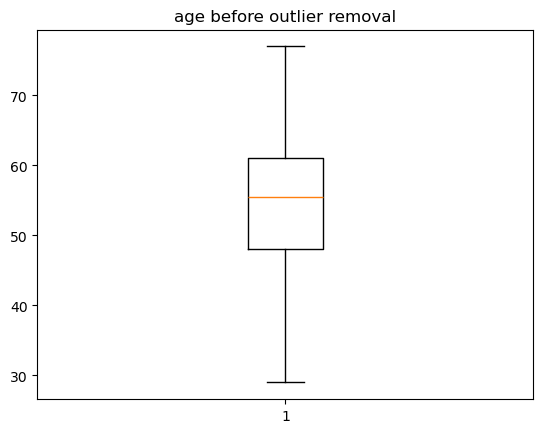

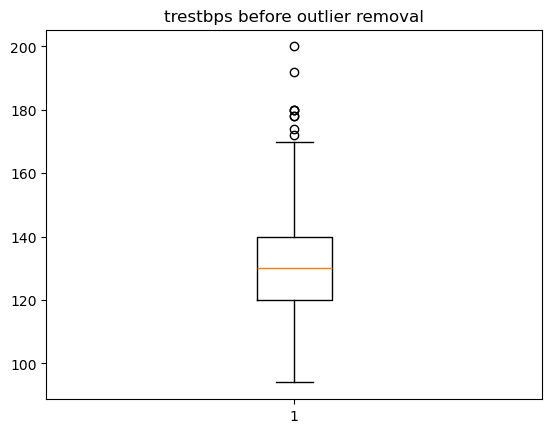

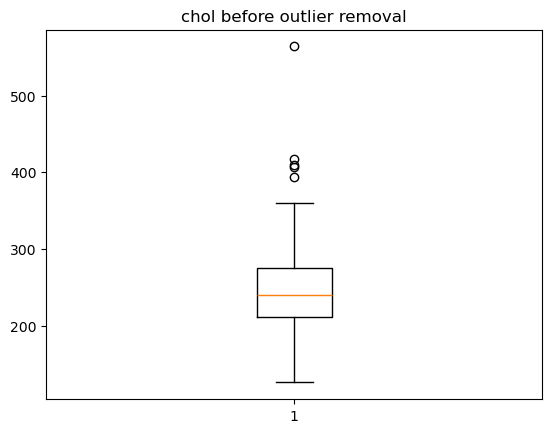

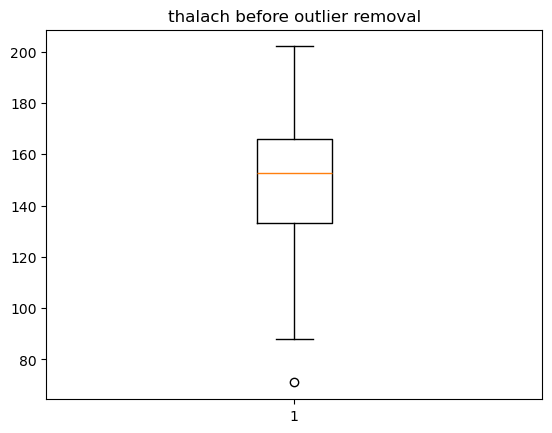

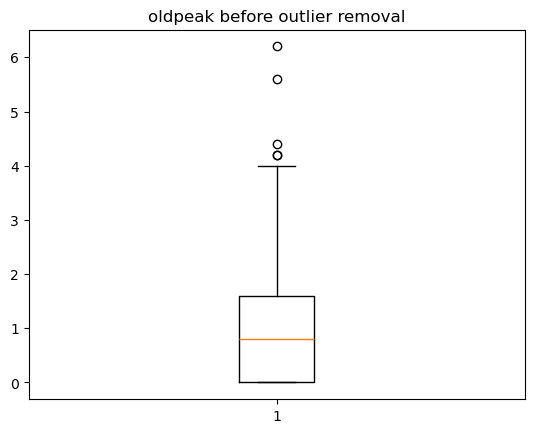

In [18]:
import matplotlib.pyplot as plt
for col in numerical_cols:
    plt.boxplot(df[col])
    plt.title(f"{col} before outlier removal")
    plt.show()

In [19]:
df_clean=df.copy()
for col in numerical_cols:
    q1=df[col].quantile(0.25)
    q3=df[col].quantile(0.75)

    IQR=q3-q1
    lower=q1-1.5*IQR
    upper=q3+1.5*IQR
    df_clean=df_clean[(df_clean[col]>=lower) & (df_clean[col]<=upper)]
    

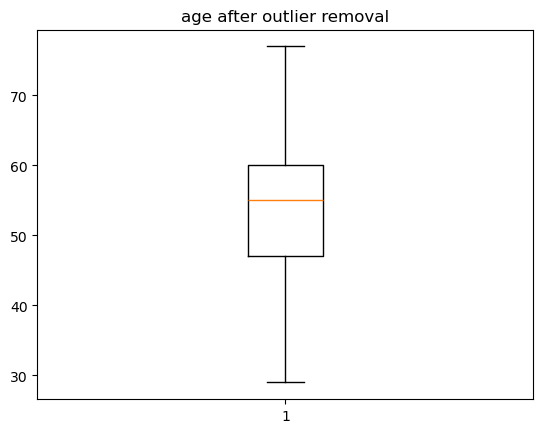

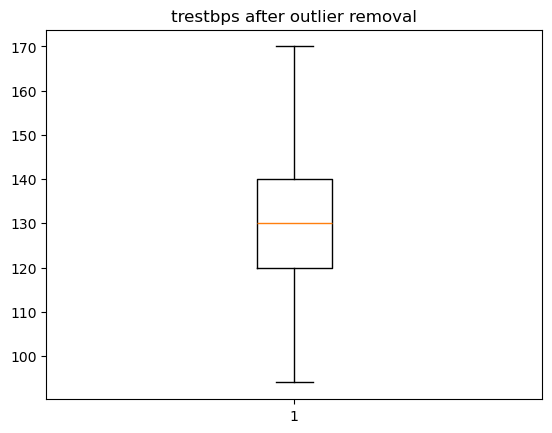

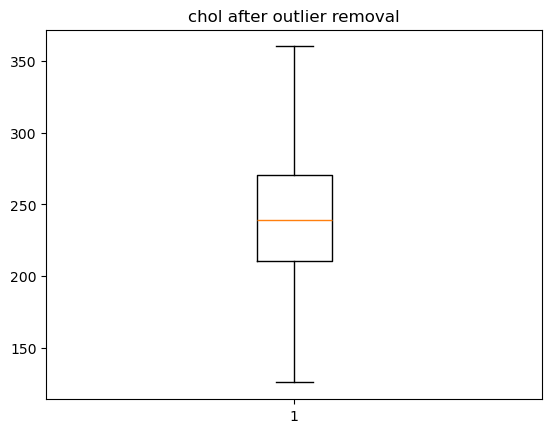

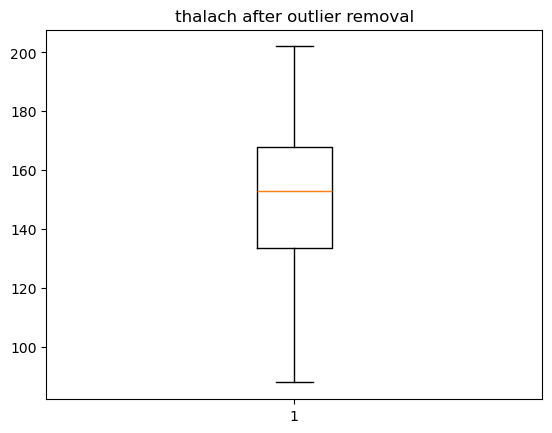

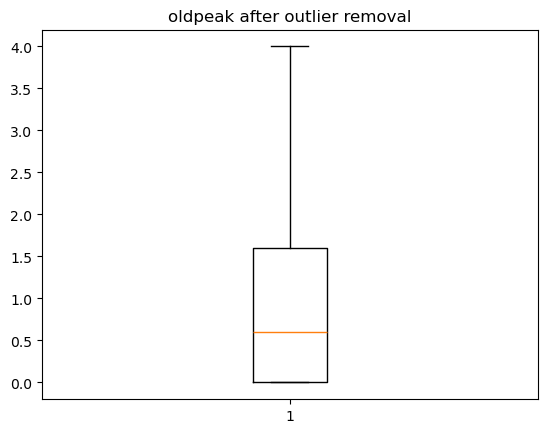

In [20]:
for col in numerical_cols:
    plt.boxplot(df_clean[col])
    plt.title(f"{col} after outlier removal")
    plt.show()

In [23]:
for cols in categorical_cols:
    print(f"{cols}")
    print(df_clean[cols].value_counts())

sex
sex
1    198
0     85
Name: count, dtype: int64
cp
cp
0    130
2     82
1     49
3     22
Name: count, dtype: int64
fbs
fbs
0    243
1     40
Name: count, dtype: int64
restecg
restecg
1    144
0    137
2      2
Name: count, dtype: int64
exang
exang
0    193
1     90
Name: count, dtype: int64
slope
slope
2    137
1    130
0     16
Name: count, dtype: int64
ca
ca
0    165
1     63
2     35
3     16
4      4
Name: count, dtype: int64
thal
thal
2    159
3    105
1     17
0      2
Name: count, dtype: int64
target
target
1    158
0    125
Name: count, dtype: int64


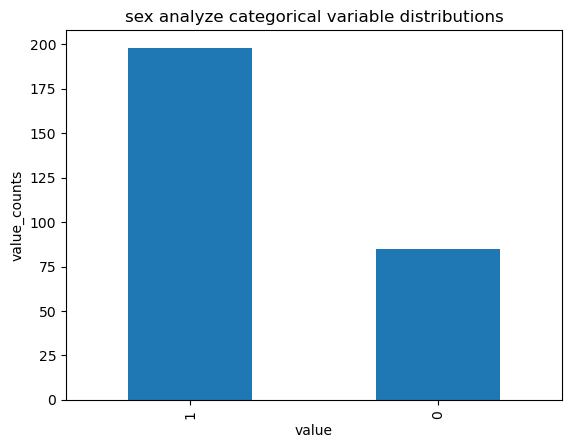

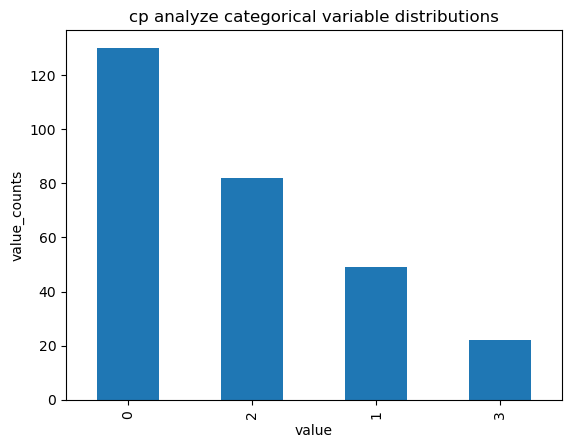

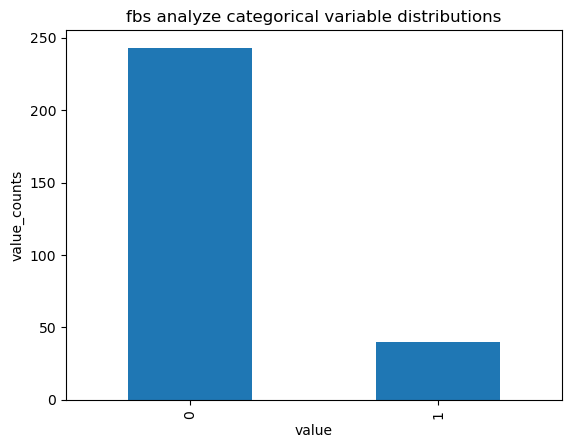

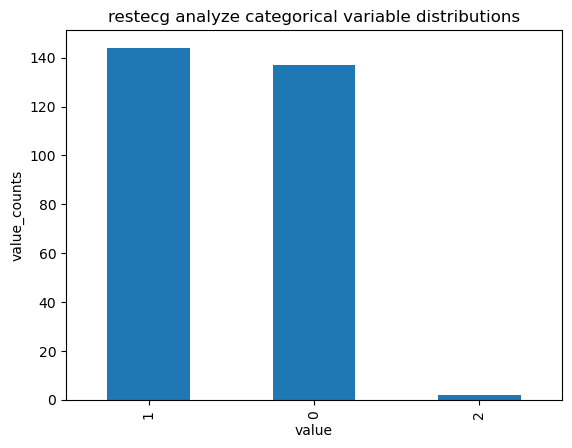

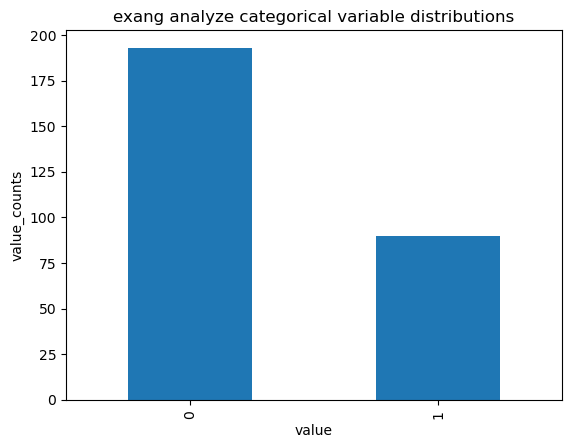

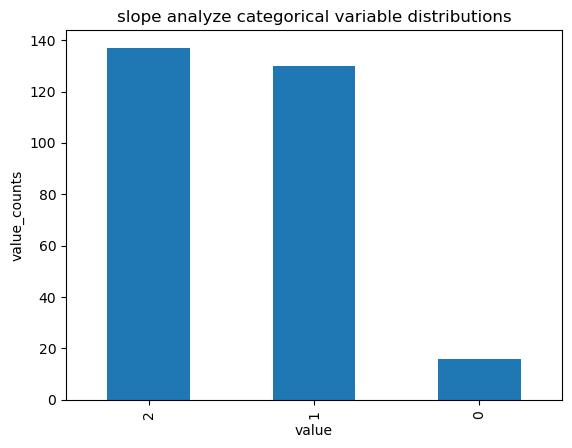

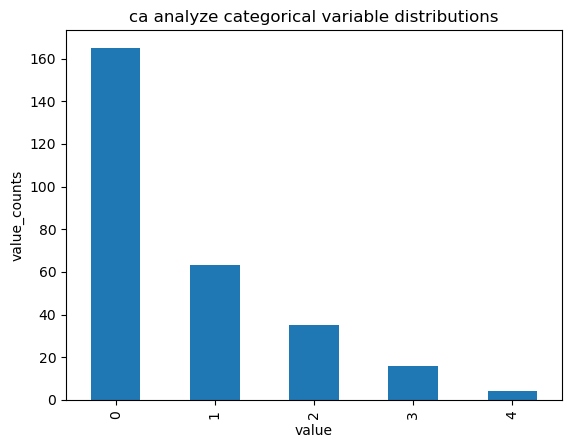

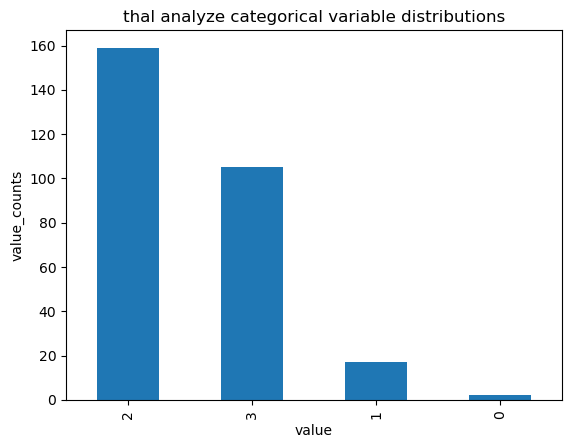

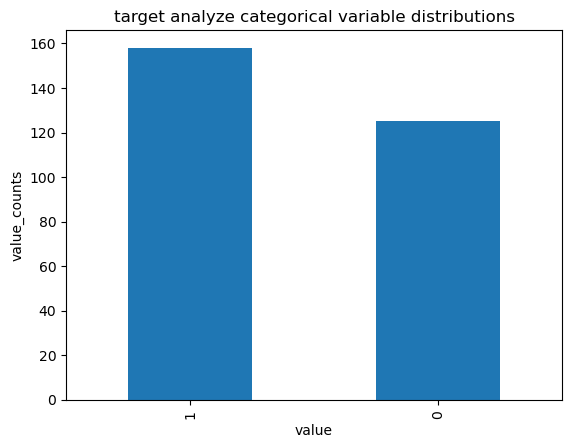

In [25]:
for cols in categorical_cols:
    df_clean[cols].value_counts().plot(kind="bar")
    plt.title(f"{cols} analyze categorical variable distributions")
    plt.xlabel("value")
    plt.ylabel("value_counts")
    plt.show()
    

In [26]:
## find correlation along the dataframe
correlation_matrix=df_clean.corr()
print(correlation_matrix)

               age       sex        cp  trestbps      chol       fbs  \
age       1.000000 -0.064118 -0.058687  0.282669  0.171015  0.106885   
sex      -0.064118  1.000000 -0.091357  0.007572 -0.123863  0.066692   
cp       -0.058687 -0.091357  1.000000  0.083242 -0.080369  0.084389   
trestbps  0.282669  0.007572  0.083242  1.000000  0.115138  0.127221   
chol      0.171015 -0.123863 -0.080369  0.115138  1.000000  0.013066   
fbs       0.106885  0.066692  0.084389  0.127221  0.013066  1.000000   
restecg  -0.110517 -0.083290  0.080836 -0.139228 -0.142285 -0.077417   
thalach  -0.411108 -0.042981  0.285605 -0.071600 -0.020128 -0.023484   
exang     0.093718  0.182596 -0.388610  0.001726  0.076547  0.006080   
oldpeak   0.209254  0.157352 -0.122582  0.144438 -0.009534  0.015070   
slope    -0.149095 -0.060014  0.095881 -0.083024  0.039352 -0.069563   
ca        0.320589  0.150209 -0.171717  0.105458  0.081070  0.156265   
thal      0.055908  0.243271 -0.179204 -0.011026  0.091667 -0.06

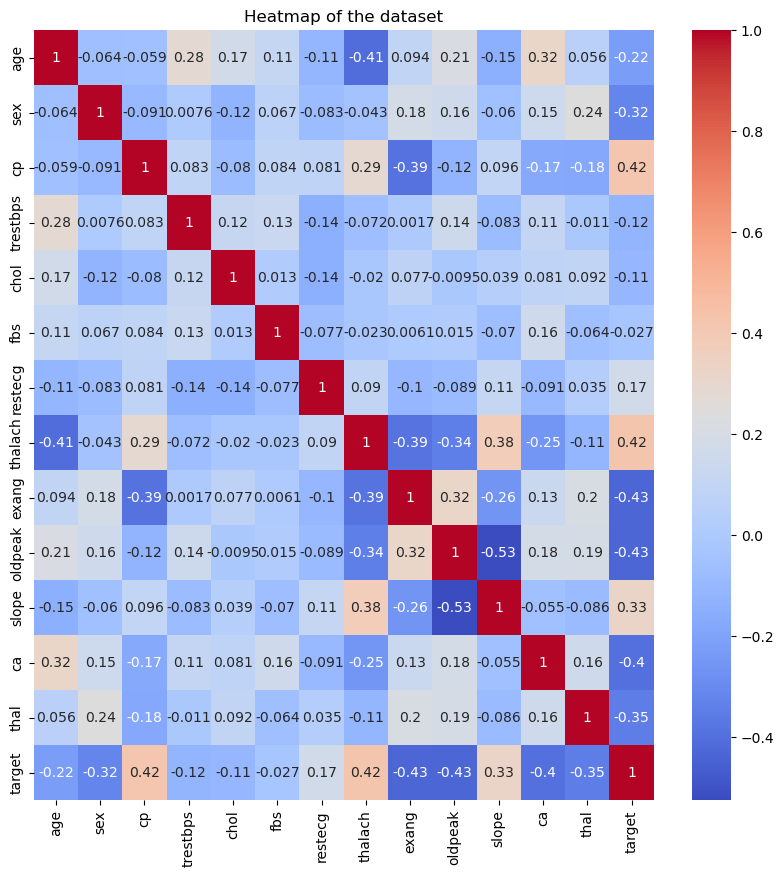

In [31]:
import seaborn as sns
plt.figure(figsize=(10,10))
sns.heatmap(correlation_matrix,annot=True,cmap='coolwarm')
plt.title("Heatmap of the dataset")
plt.show()

In [32]:
df_clean.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [33]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
df_clean[numerical_cols]=scaler.fit_transform(df_clean[numerical_cols])
print(df_clean)

          age  sex  cp  trestbps      chol  fbs  restecg   thalach  exang  \
0   -0.224919    1   0 -0.317917 -0.680075    0        1  0.796365      0   
1   -0.115174    1   0  0.658608 -0.881981    1        0  0.222452      1   
2    1.750489    1   0  0.984117 -1.532566    0        1 -1.101964      1   
3    0.762785    1   0  1.179422 -0.881981    0        1  0.487335      0   
4    0.872530    0   0  0.528405  1.159512    1        1 -1.940760      0   
..        ...  ...  ..       ...       ...  ...      ...       ...    ...   
723  1.530999    0   2 -0.643426 -0.702509    0        0 -1.543436      0   
733 -1.102878    0   2 -1.424646 -2.272888    0        1  1.105396      0   
739 -0.224919    1   0 -0.122612  0.284587    0        1  0.487335      1   
843  0.543295    1   3  1.960642  0.688398    0        0 -1.101964      0   
878 -0.005429    1   0 -0.643426 -1.218491    0        1 -1.631730      0   

      oldpeak  slope  ca  thal  target  
0    0.046903      2   2     3    

In [36]:
from sklearn.model_selection import train_test_split
x_regression=df_clean.drop("chol",axis=1)
y_regression=df_clean["chol"]

In [38]:
x_train_reg,x_test_reg,y_train_reg,y_test_reg=train_test_split(x_regression,y_regression,train_size=0.8,random_state=42)

In [39]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(x_train_reg,y_train_reg)

LinearRegression()

In [40]:
y_pred_reg=lr.predict(x_test_reg)

In [42]:
print(y_pred_reg)

[ 0.37028734 -0.44793443  0.24153333  0.25903445  0.14957917  0.17917884
 -0.14415843  0.20714271  0.22740046 -0.08286946 -0.15851671  0.36837385
  0.17358462  0.51802279  0.27646135 -0.15719278 -0.12600562  0.1692331
 -0.12063211 -0.04070717 -0.34594668 -0.0623807   0.05211207  0.09748743
 -0.73172356  0.32979334 -0.19606102 -0.08942185  0.14071496 -0.42309658
  0.15682138 -0.1245017   0.69862094 -0.22964879  0.24119665  0.03204721
 -0.14682092 -0.05440353  0.14489764 -0.26614351 -0.51077459  0.69970172
  0.70443874 -0.06570679  0.50413044  0.10643484 -0.39352056  0.81811915
  0.07590962  0.22133404 -0.23056936  0.01201968 -0.44222268  0.20404925
 -0.1501456   0.68609097 -0.08603408]


In [43]:
from sklearn.metrics import (mean_absolute_error,mean_squared_error,r2_score)
print("MAE:",mean_absolute_error(y_test_reg, y_pred_reg))
print("MSE:",mean_squared_error(y_test_reg, y_pred_reg))
print("R2 Score:",r2_score(y_test_reg, y_pred_reg))

MAE: 0.826859954896562
MSE: 1.0864779419617858
R2 Score: -0.08995134489274847


In [44]:
## Classification models

In [45]:
x_classification=df_clean.drop('target',axis=1)
y_classification=df_clean['target']
x_train_class,x_test_class,y_train_class,y_test_class=train_test_split(x_classification,y_classification,train_size=0.8)

In [46]:
from sklearn.linear_model import LogisticRegression
log_r=LogisticRegression()
log_r.fit(x_train_class,y_train_class)

LogisticRegression()

In [47]:
y_pred_log_r=log_r.predict(x_test_class)

In [49]:
from sklearn.metrics import classification_report
cm = classification_report(
    y_test_class,
    y_pred_log_r)
print(cm)

              precision    recall  f1-score   support

           0       0.94      0.73      0.82        22
           1       0.85      0.97      0.91        35

    accuracy                           0.88        57
   macro avg       0.90      0.85      0.86        57
weighted avg       0.89      0.88      0.87        57



In [50]:
from sklearn.neighbors import KNeighborsClassifier
knn_model=KNeighborsClassifier(n_neighbors=5)

In [51]:
knn_model.fit(x_train_class,y_train_class)


KNeighborsClassifier()

In [52]:
y_pred_knn=knn_model.predict(x_test_class)

In [53]:

clas_knn= classification_report(
    y_test_class,
    y_pred_knn
)

print(clas_knn)

              precision    recall  f1-score   support

           0       0.89      0.77      0.83        22
           1       0.87      0.94      0.90        35

    accuracy                           0.88        57
   macro avg       0.88      0.86      0.87        57
weighted avg       0.88      0.88      0.88        57



In [54]:
## naive baiyes

In [56]:
from sklearn.naive_bayes import GaussianNB
naive=GaussianNB()
naive.fit(x_train_class,y_train_class)

GaussianNB()

In [57]:
y_pred_naive=naive.predict(x_test_class)

In [59]:
clas_naive=classification_report(
    y_test_class,
    y_pred_naive)
print(clas_naive)

              precision    recall  f1-score   support

           0       0.86      0.82      0.84        22
           1       0.89      0.91      0.90        35

    accuracy                           0.88        57
   macro avg       0.87      0.87      0.87        57
weighted avg       0.88      0.88      0.88        57

